In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use("dark_background")
sns.set_palette("husl")

# Load data
df = pd.read_csv("../data/processed/reviews_final.csv")
kw = pd.read_csv("../data/processed/pb_keywords_combined.csv")
top = pd.read_csv("../data/processed/pb_top_product_per_category.csv")

print(f"Reviews: {len(df)}")
print(f"Keywords: {len(kw)}")
df.head()

Reviews: 3000
Keywords: 5422


,product,brand,rating,review_text,review_title,review_date,sentiment,sentiment_score,keywords
0,"Amazon Fire HD 8 with Alexa (8"" HD Display Tab...",Amazon,5,Bought this as a gift for my 66 yr old dad. He...,Great Tablet,2018-01-05 00:00:00+00:00,positive,0.9706,"ipads, expensive ipads, learn navigate"
1,AmazonBasics AAA Performance Alkaline Batterie...,Amazonbasics,5,yea ther good value,Five Stars,2015-10-12 00:00:00+00:00,positive,0.6420,"good value, yea ther, ther good"
2,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",Amazon,5,I love the Kindle Fire! So far it has great sp...,Kindle Fire 8,2017-12-27 00:00:00+00:00,positive,0.9904,"love kindle, kindle, kindle far"
3,AmazonBasics AAA Performance Alkaline Batterie...,Amazonbasics,5,Strong good batteries.,Good,2016-01-28 00:00:00+00:00,positive,0.9196,"good batteries, batteries, strong good"
4,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",Amazon,5,This is a great tablet at a great price! We bo...,Great tablet!,2016-11-20 00:00:00+00:00,positive,0.9905,"tablet great, great tablet, tablet"


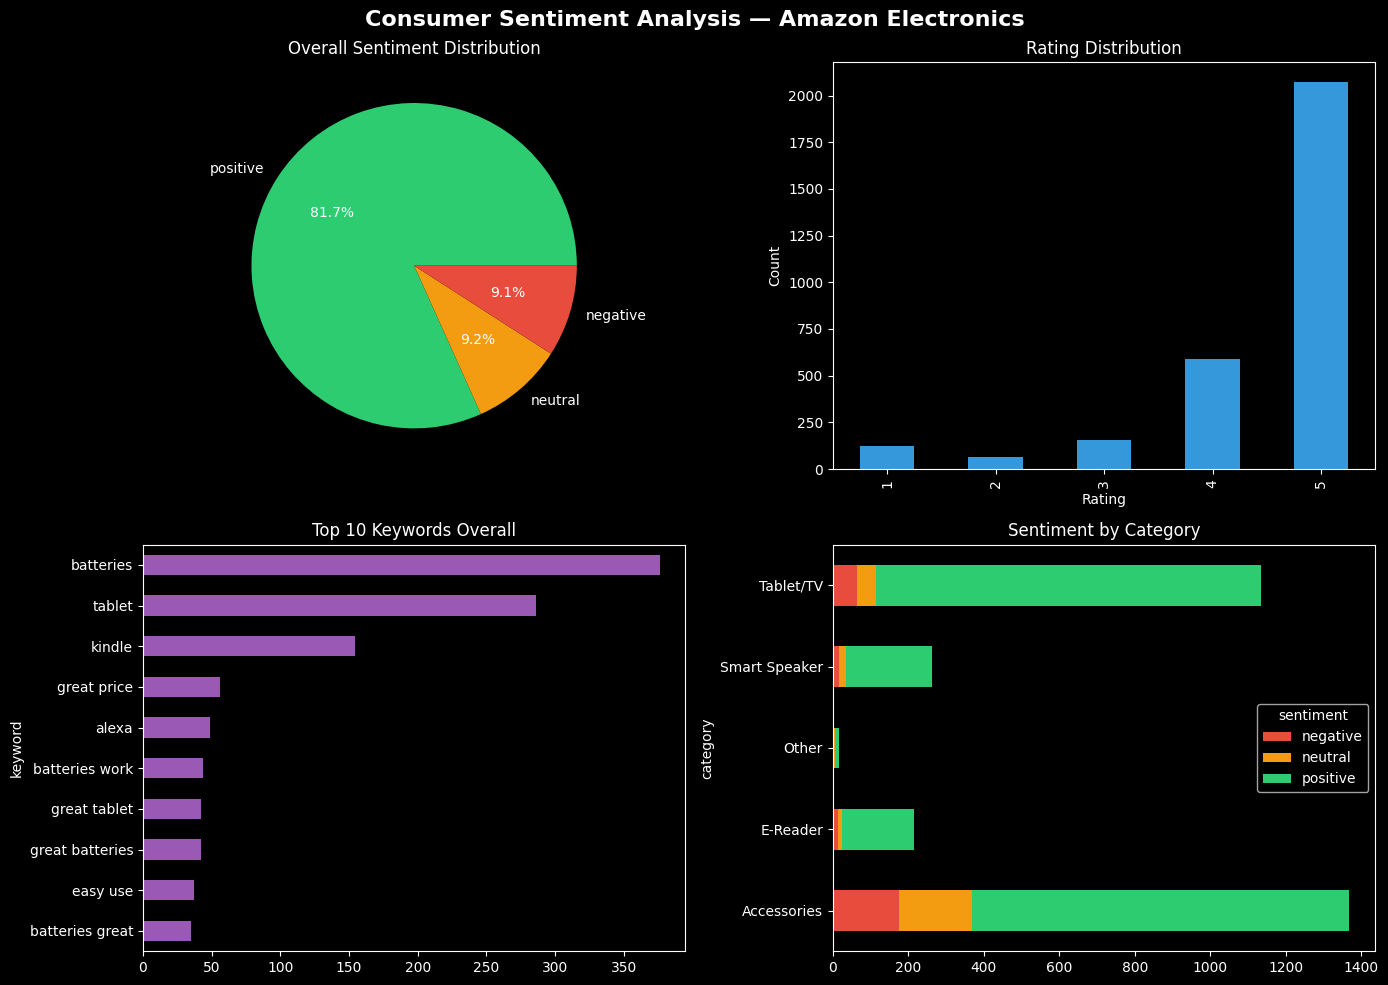

Saved!


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Consumer Sentiment Analysis — Amazon Electronics", fontsize=16, fontweight="bold")

# 1. Sentiment distribution
sentiment_counts = df["sentiment"].value_counts()
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
axes[0, 0].pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%", colors=colors)
axes[0, 0].set_title("Overall Sentiment Distribution")

# 2. Rating distribution
df["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1], color="#3498db")
axes[0, 1].set_title("Rating Distribution")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].set_ylabel("Count")

# 3. Top 10 keywords
top_kw = kw.groupby("keyword")["count"].sum().nlargest(10).sort_values()
top_kw.plot(kind="barh", ax=axes[1, 0], color="#9b59b6")
axes[1, 0].set_title("Top 10 Keywords Overall")

# 4. Sentiment by category
category_sentiment = df.copy()
category_sentiment["category"] = category_sentiment["product"].apply(lambda x: 
    "E-Reader" if "Kindle" in str(x) else
    "Tablet/TV" if any(w in str(x) for w in ["Fire", "Tablet"]) else
    "Smart Speaker" if any(w in str(x) for w in ["Echo", "Tap", "Dot", "Alexa"]) else
    "Accessories" if any(w in str(x) for w in ["Battery", "Batteries"]) else "Other"
)
cat_sent = category_sentiment.groupby(["category", "sentiment"]).size().unstack(fill_value=0)
cat_sent.plot(kind="barh", stacked=True, ax=axes[1, 1], color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[1, 1].set_title("Sentiment by Category")

plt.tight_layout()
plt.savefig("../data/processed/analysis_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [11]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

categories_list = ["Accessories", "Tablet/TV", "Smart Speaker", "E-Reader", "Other"]
insights = {}

def get_cat(x):
    x = str(x)
    if "Kindle" in x: return "E-Reader"
    elif any(w in x for w in ["Fire", "Tablet"]): return "Tablet/TV"
    elif any(w in x for w in ["Echo", "Tap", "Dot", "Alexa"]): return "Smart Speaker"
    elif any(w in x for w in ["Battery", "Batteries"]): return "Accessories"
    else: return "Other"

df["category"] = df["product"].apply(get_cat)

for category in categories_list:
    cat_df = df[df["category"] == category]
    cat_kw = kw[kw["category"] == category]
    
    total = len(cat_df)
    if total == 0:
        continue
        
    pos_rate = round(len(cat_df[cat_df["sentiment"] == "positive"]) / total * 100, 1)
    
    top_pos = cat_kw[cat_kw["sentiment"] == "positive"].nlargest(5, "count")["keyword"].tolist()
    top_neg = cat_kw[cat_kw["sentiment"] == "negative"].nlargest(5, "count")["keyword"].tolist()
    
    insights[category] = {
        "total": total,
        "positive_rate": pos_rate,
        "loved_for": ", ".join(top_pos),
        "complaints": ", ".join(top_neg)
    }
    
    print(f"\n{'='*50}")
    print(f"📦 {category}")
    print(f"{'='*50}")
    print(f"Reviews analysed : {total}")
    print(f"Positive rate    : {pos_rate}%")
    print(f"Loved for        : {', '.join(top_pos)}")
    print(f"Complaints about : {', '.join(top_neg)}")

print("\nDone!")


📦 Accessories
Reviews analysed : 1369
Positive rate    : 73.0%
Loved for        : batteries, great price, great batteries, batteries work, batteries great
Complaints about : batteries, amazon batteries, don long, long, worst batteries

📦 Tablet/TV
Reviews analysed : 1135
Positive rate    : 90.0%
Loved for        : tablet, kindle, great tablet, easy use, apps
Complaints about : tablet, kindle, amazon apps, android tablet, decent tablet

📦 Smart Speaker
Reviews analysed : 264
Positive rate    : 87.1%
Loved for        : alexa, echo, amazon echo, echo plus, smart home
Complaints about : alexa, best buy, alexa knows, alexa like, alexa say

📦 E-Reader
Reviews analysed : 215
Positive rate    : 88.8%
Loved for        : kindle, tablet, reader, love kindle, best kindle
Complaints about : kindle, apps, amazon kindle, apps pain, backlit

📦 Other
Reviews analysed : 17
Positive rate    : 64.7%
Loved for        : backpack, backpack does, backpack great, cds cases, cheap laptop
Complaints about : fit